In [1]:
import os
import cv2
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

In [2]:
data_dir = '/work/cvcs2026/LZMM/OpenEDS/openEDS/openEDS'

In [3]:
def explore_directory(path, max_depth=3, current_depth=0):
    """Recursively explore directory structure"""
    if current_depth >= max_depth:
        return
    
    try:
        items = sorted(os.listdir(path))
        for item in items[:3]:  # Show first 3 items
            item_path = os.path.join(path, item)
            indent = "  " * current_depth
            if os.path.isdir(item_path):
                print(f"{indent}{item}/")
                explore_directory(item_path, max_depth, current_depth + 1)
            else:
                size = os.path.getsize(item_path)
                size_str = f"{size/1024:.1f}KB" if size < 1024*1024 else f"{size/(1024*1024):.1f}MB"
                print(f"{indent}{item} ({size_str})")
        
        if len(items) > 10:
            print(f"{indent}... and {len(items) - 10} more items")
    except PermissionError:
        print(f"{indent}Permission denied")

print("\n" + "="*60)
print("DATASET STRUCTURE")
print("="*60)
explore_directory(data_dir, max_depth=3)


DATASET STRUCTURE
S_0/
  0.npy (250.1KB)
  0.png (144.1KB)
  1.npy (250.1KB)
  ... and 316 more items
S_1/
  0.npy (250.1KB)
  0.png (138.1KB)
  1.npy (250.1KB)
  ... and 305 more items
S_10/
  0.npy (250.1KB)
  0.png (151.8KB)
  1.npy (250.1KB)
  ... and 328 more items
... and 181 more items



Found first sample!
Image: 0.png
Label: label_123.npy
Directory: /work/cvcs2026/LZMM/OpenEDS/openEDS/openEDS/S_131

Image loaded successfully!
Image shape: (400, 640)
Image dtype: uint8
Pixel value range: [7, 255]


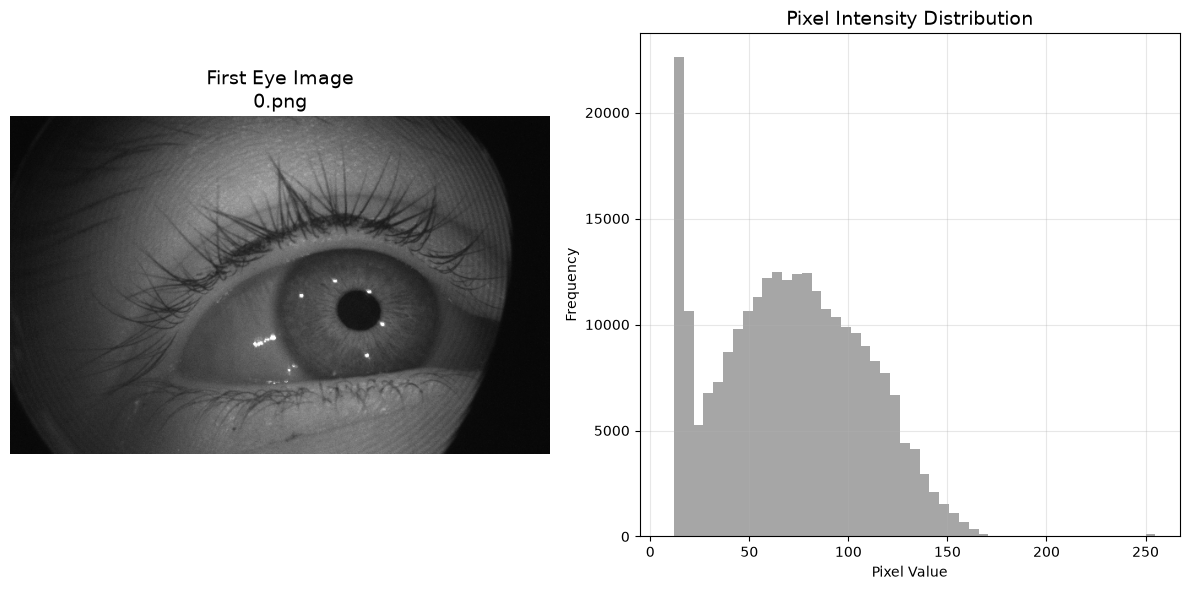


Sample pixel values from center region:
[[83 71 71 68 63]
 [73 72 67 65 60]
 [72 77 71 63 65]
 [74 72 77 66 68]
 [72 77 75 70 68]]


In [4]:
def find_first_sample(data_dir):
    """Find the first valid image and label pair"""
    
    # Try common structures
    for root, dirs, files in os.walk(data_dir):
        # Look for .npy files (labels)
        npy_files = [f for f in files if f.endswith('.npy') and 'label' in f.lower()]
        
        if npy_files:
            # Look for images
            label_file = os.path.join(root, npy_files[0])
            
            # Look for image files
            img_files = sorted([f for f in files if f.endswith(('.png', '.jpg', '.jpeg'))])
            
            if img_files:
                img_file = os.path.join(root, img_files[0])
                
                return {
                    'image_path': img_file,
                    'label_path': label_file,
                    'directory': root,
                    'image_name': img_files[0],
                    'label_name': npy_files[0]
                }
    
    return None

first_sample = find_first_sample(data_dir)

if first_sample:
    print("\nFound first sample!")
    print(f"Image: {first_sample['image_name']}")
    print(f"Label: {first_sample['label_name']}")
    print(f"Directory: {first_sample['directory']}")
    # Load image
    image = cv2.imread(first_sample['image_path'], cv2.IMREAD_GRAYSCALE)
    
    if image is None:
        print("Failed to load image")
    else:
        print(f"\nImage loaded successfully!")
        print(f"Image shape: {image.shape}")
        print(f"Image dtype: {image.dtype}")
        print(f"Pixel value range: [{image.min()}, {image.max()}]")
        
        # Display image
        plt.figure(figsize=(12, 6))
        
        plt.subplot(1, 2, 1)
        plt.imshow(image, cmap='gray')
        plt.title(f'First Eye Image\n{first_sample["image_name"]}', fontsize=14)
        plt.axis('off')
        
        # Show histogram
        plt.subplot(1, 2, 2)
        plt.hist(image.ravel(), bins=50, color='gray', alpha=0.7)
        plt.title('Pixel Intensity Distribution', fontsize=14)
        plt.xlabel('Pixel Value')
        plt.ylabel('Frequency')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Show some pixel values
        print(f"\nSample pixel values from center region:")
        h, w = image.shape
        center_region = image[h//2-2:h//2+3, w//2-2:w//2+3]
        print(center_region)
else:
    print("\nCould not find image-label pair")
    print("Let's explore manually...")

In [5]:
data_dir = '/work/cvcs2026/LZMM/OpenEDS'
openeds_path = os.path.join(data_dir, 'openEDS')

print("Exploring openEDS folder structure...\n")
print("="*60)

# First level
items = sorted(os.listdir(openeds_path))
print(f"Found {len(items)} items in openEDS/\n")

for item in items[:15]:  # Show first 15
    item_path = os.path.join(openeds_path, item)
    if os.path.isdir(item_path):
        # It's a directory - look inside
        try:
            subfiles = os.listdir(item_path)
            num_png = len([f for f in subfiles if f.endswith('.png')])
            num_npy = len([f for f in subfiles if f.endswith('.npy')])
            
            print(f"{item}/")
            print(f"   └─ {len(subfiles)} files ({num_png} images, {num_npy} .npy)")
            
            # Show first few files
            for sf in sorted(subfiles)[:4]:
                print(f"      - {sf}")
            if len(subfiles) > 4:
                print(f"      ... and {len(subfiles)-4} more")
            print()
            
        except Exception as e:
            print(f"{item}/ (can't read: {e})\n")
    else:
        # It's a file
        size = os.path.getsize(item_path) / 1024
        print(f"{item} ({size:.1f} KB)\n")

if len(items) > 15:
    print(f"... and {len(items)-15} more items")

print("="*60)

# Now search for all images and labels
print("\nSearching for all data files...")
print("="*60)

all_images = []
all_labels = []

for root, dirs, files in os.walk(openeds_path):
    for file in files:
        full_path = os.path.join(root, file)
        if file.endswith(('.png', '.jpg', '.jpeg')):
            all_images.append({
                'path': full_path,
                'name': file,
                'dir': root,
                'parent': os.path.basename(root)
            })
        elif file.endswith('.npy'):
            all_labels.append({
                'path': full_path,
                'name': file,
                'dir': root,
                'parent': os.path.basename(root)
            })

print(f"\nTotal images found: {len(all_images)}")
print(f"Total .npy files found: {len(all_labels)}")

if all_images:
    print(f"\nFirst 3 image examples:")
    for i, img in enumerate(all_images[:3]):
        print(f"  {i+1}. {img['parent']}/{img['name']}")

if all_labels:
    print(f"\nFirst 3 label examples:")
    for i, lbl in enumerate(all_labels[:3]):
        print(f"  {i+1}. {lbl['parent']}/{lbl['name']}")

print("\n" + "="*60)

Exploring openEDS folder structure...

Found 1 items in openEDS/

openEDS/
   └─ 191 files (0 images, 0 .npy)
      - S_0
      - S_1
      - S_10
      - S_101
      ... and 187 more


Searching for all data files...

Total images found: 93269
Total .npy files found: 61844

First 3 image examples:
  1. S_131/6.png
  2. S_131/88.png
  3. S_131/58.png

First 3 label examples:
  1. S_131/104.npy
  2. S_131/25.npy
  3. S_131/35.npy



In [6]:
data_dir = '/work/cvcs2026/LZMM/OpenEDS'
openeds_path = os.path.join(data_dir, 'openEDS', 'openEDS')

print("Loading first image and label...\n")
print("="*60)

# Get the first subject folder
subjects = sorted([d for d in os.listdir(openeds_path) if d.startswith('S_')])
first_subject = subjects[0]
subject_path = os.path.join(openeds_path, first_subject)

print(f"Using subject: {first_subject}")
print(f"Path: {subject_path}\n")

# List files in this subject folder
files = sorted(os.listdir(subject_path))
images = [f for f in files if f.endswith('.png')]
labels = [f for f in files if f.endswith('.npy')]

print(f"Found {len(images)} images and {len(labels)} label files")
print(f"First few images: {images[:5]}")
print(f"First few labels: {labels[:5]}\n")

# Take the first image
first_image_name = images[0]
first_image_path = os.path.join(subject_path, first_image_name)

# Try to find matching label
# Extract number from image filename (e.g., "94.png" -> "94")
img_number = first_image_name.split('.')[0]
label_name = f"{img_number}.npy"
label_path = os.path.join(subject_path, label_name)

print(f"Image: {first_image_name}")
print(f"Looking for label: {label_name}")

# Check if matching label exists
if not os.path.exists(label_path):
    print(f"Exact match not found, using first available label: {labels[0]}")
    label_path = os.path.join(subject_path, labels[0])
    label_name = labels[0]

print(f"Label: {label_name}\n")
print("="*60)

# Load image
image = cv2.imread(first_image_path, cv2.IMREAD_GRAYSCALE)
print(f"\nImage loaded!")
print(f"  Shape: {image.shape}")
print(f"  Dtype: {image.dtype}")
print(f"  Range: [{image.min()}, {image.max()}]")

# Load label
label_data = np.load(label_path)
print(f"\nLabel loaded!")
print(f"  Shape: {label_data.shape}")
print(f"  Dtype: {label_data.dtype}")
print(f"  Content:\n{label_data}")

# Check if it's a gaze vector
if label_data.shape == (3,):
    print(f"\nThis is a 3D gaze vector!")
    x, y, z = label_data
    print(f"  x = {x:.6f}")
    print(f"  y = {y:.6f}")
    print(f"  z = {z:.6f}")
    print(f"  Magnitude = {np.linalg.norm(label_data):.6f}")
    
    # Convert to 2D angles
    theta_h = np.degrees(np.arctan2(x, z))
    theta_v = np.degrees(np.arctan2(y, z))
    
    print(f"\n2D Gaze Angles:")
    print(f"  Horizontal: {theta_h:7.2f}°")
    print(f"  Vertical:   {theta_v:7.2f}°")
    
    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1. Original image
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title(f'Original Image\n{first_subject}/{first_image_name}', 
                      fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # 2. Image with gaze arrow
    img_rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    h, w = image.shape
    cx, cy = w//2, h//2
    
    # Draw gaze arrow
    arrow_len = 80
    ex = int(cx + arrow_len * np.sin(np.radians(theta_h)))
    ey = int(cy - arrow_len * np.sin(np.radians(theta_v)))
    
    cv2.arrowedLine(img_rgb, (cx, cy), (ex, ey), (255, 0, 0), 3, tipLength=0.3)
    cv2.circle(img_rgb, (cx, cy), 5, (0, 255, 0), -1)
    
    axes[1].imshow(img_rgb)
    axes[1].set_title(f'Gaze Direction\nH: {theta_h:.1f}° | V: {theta_v:.1f}°', 
                      fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    # 3. Gaze vector visualization
    axes[2].set_xlim(-15, 15)
    axes[2].set_ylim(-15, 15)
    axes[2].axhline(0, color='k', linewidth=0.5, alpha=0.3)
    axes[2].axvline(0, color='k', linewidth=0.5, alpha=0.3)
    axes[2].grid(True, alpha=0.2)
    
    axes[2].arrow(0, 0, theta_h, theta_v, 
                  head_width=1.5, head_length=1, 
                  fc='red', ec='red', linewidth=2)
    
    axes[2].set_xlabel('Horizontal (degrees)', fontsize=11)
    axes[2].set_ylabel('Vertical (degrees)', fontsize=11)
    axes[2].set_title('Gaze Angle Plot', fontsize=12, fontweight='bold')
    axes[2].set_aspect('equal')
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"Subject: {first_subject}")
    print(f"Image: {first_image_name} | Shape: {image.shape}")
    print(f"Label: {label_name}")
    print(f"3D Gaze: [{x:.4f}, {y:.4f}, {z:.4f}]")
    print(f"2D Angles: H={theta_h:.2f}°, V={theta_v:.2f}°")
    print("="*60)
    
elif len(label_data.shape) == 2:
    print(f"\nThis label file contains {label_data.shape[0]} gaze vectors")
    print(f"   (It's a sequence, not a single frame label)")
    print(f"\nFirst 5 gaze vectors:")
    print(label_data[:5])
    
else:
    print(f"\nUnexpected label format: {label_data.shape}")
    print(f"Content preview:\n{label_data}")

Loading first image and label...

Using subject: S_0
Path: /work/cvcs2026/LZMM/OpenEDS/openEDS/openEDS/S_0

Found 156 images and 170 label files
First few images: ['0.png', '1.png', '10.png', '100.png', '101.png']
First few labels: ['0.npy', '1.npy', '10.npy', '100.npy', '101.npy']

Image: 0.png
Looking for label: 0.npy
Label: 0.npy


Image loaded!
  Shape: (400, 640)
  Dtype: uint8
  Range: [13, 255]

Label loaded!
  Shape: (400, 640)
  Dtype: uint8
  Content:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

This label file contains 400 gaze vectors
   (It's a sequence, not a single frame label)

First 5 gaze vectors:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


OPENEDS SEMANTIC SEGMENTATION DATASET

Image: (400, 640) | Range: [13, 255]
Mask:  (400, 640) | Classes: [0 1 2 3]

Pixel counts per class:
  0 - Background  : 212979 pixels (83.19%)
  1 - Sclera      :  18797 pixels ( 7.34%)
  2 - Iris        :  23170 pixels ( 9.05%)
  3 - Pupil       :   1054 pixels ( 0.41%)



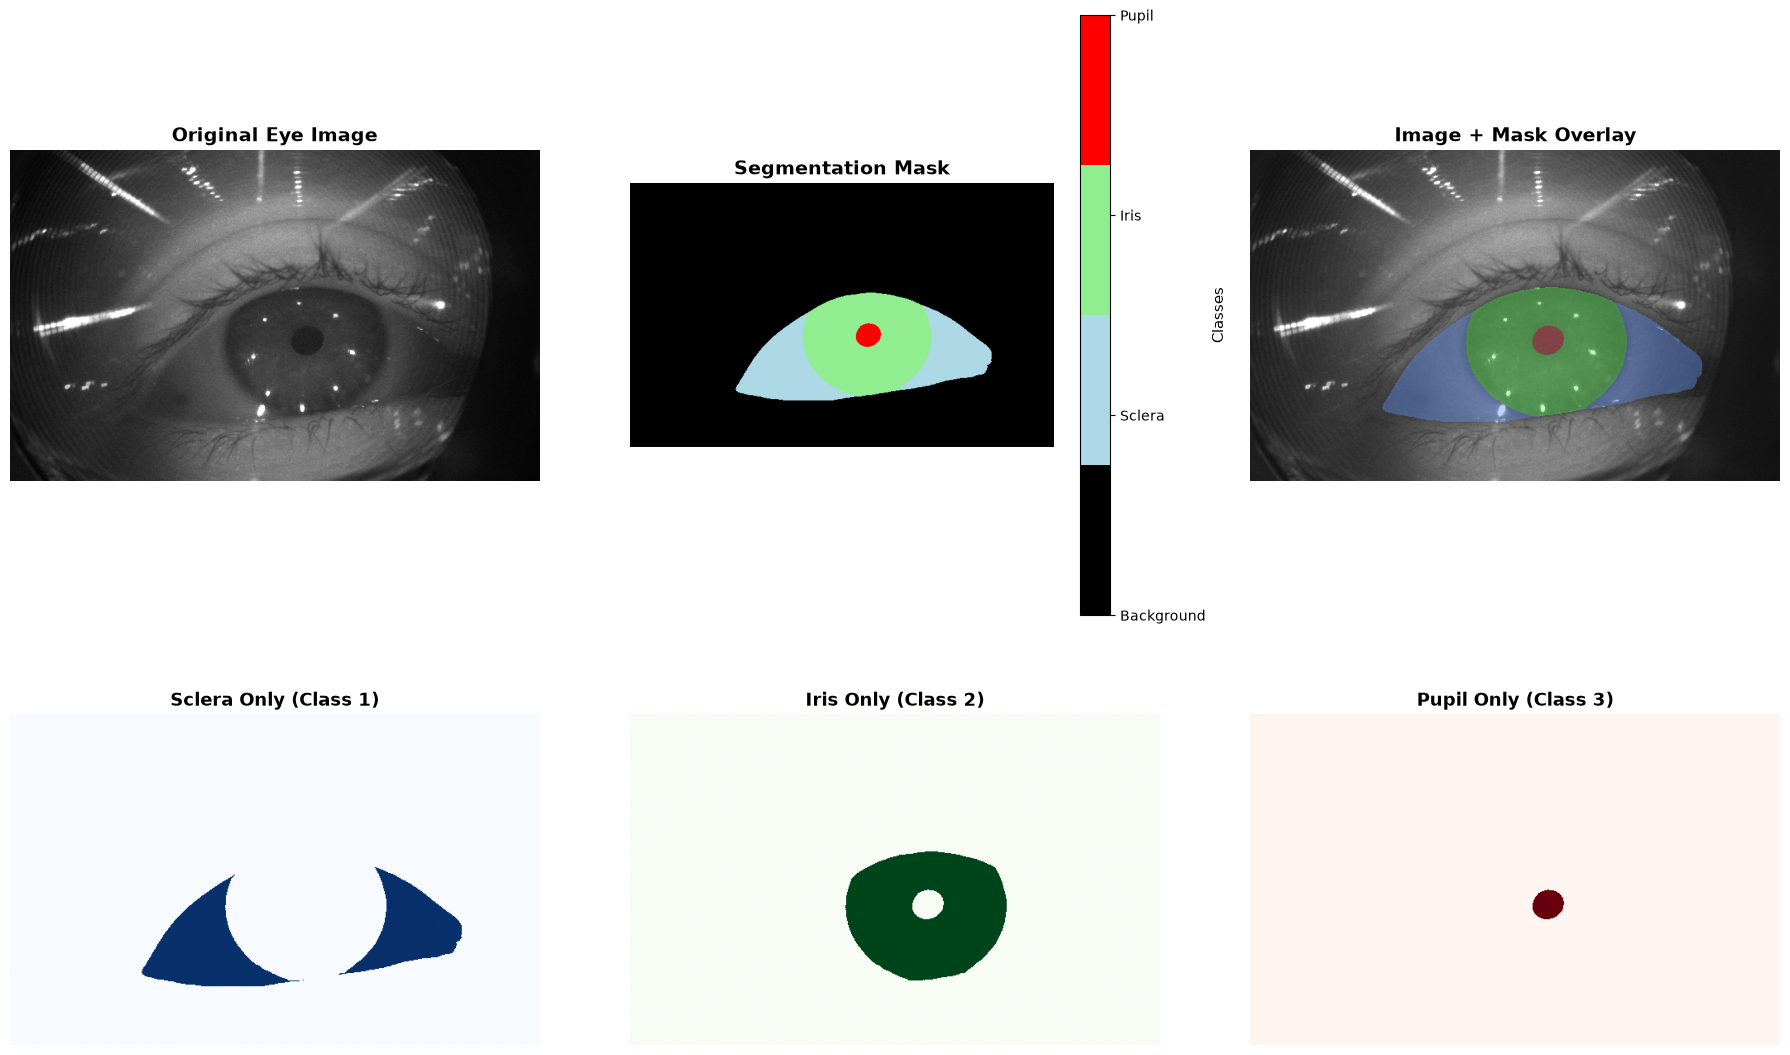


DATASET INFORMATION
This is OpenEDS Semantic Segmentation Dataset
Labels are pixel-level segmentation masks, NOT gaze vectors

For gaze prediction (3D gaze vectors), you need:
  - OpenEDS2020 Gaze Prediction Dataset
  - Labels should be .npy files with shape (N, 3)
  - I will calculate gaze vectors from the segmentation


In [7]:
data_dir = '/work/cvcs2026/LZMM/OpenEDS'
openeds_path = os.path.join(data_dir, 'openEDS', 'openEDS')

# Load first image and label
first_subject = 'S_0'
subject_path = os.path.join(openeds_path, first_subject)

# Load image 0.png and label 0.npy
image_path = os.path.join(subject_path, '0.png')
label_path = os.path.join(subject_path, '0.npy')

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
mask = np.load(label_path)

print("="*60)
print("OPENEDS SEMANTIC SEGMENTATION DATASET")
print("="*60)
print(f"\nImage: {image.shape} | Range: [{image.min()}, {image.max()}]")
print(f"Mask:  {mask.shape} | Classes: {np.unique(mask)}")

# Count pixels per class
unique, counts = np.unique(mask, return_counts=True)
print(f"\nPixel counts per class:")
class_names = {0: 'Background', 1: 'Sclera', 2: 'Iris', 3: 'Pupil'}
for cls, count in zip(unique, counts):
    percentage = (count / mask.size) * 100
    name = class_names.get(cls, f'Unknown({cls})')
    print(f"  {cls} - {name:12s}: {count:6d} pixels ({percentage:5.2f}%)")

print("\n" + "="*60)

# Create colored segmentation overlay
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Original image
axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Original Eye Image', fontsize=14, fontweight='bold')
axes[0, 0].axis('off')

# 2. Segmentation mask (colored)
# Define colors: background=black, sclera=blue, iris=green, pupil=red
colors = ['black', 'lightblue', 'lightgreen', 'red']
cmap = ListedColormap(colors)

im = axes[0, 1].imshow(mask, cmap=cmap, vmin=0, vmax=3)
axes[0, 1].set_title('Segmentation Mask', fontsize=14, fontweight='bold')
axes[0, 1].axis('off')

# Add colorbar
cbar = plt.colorbar(im, ax=axes[0, 1], ticks=[0, 1, 2, 3])
cbar.set_label('Classes', fontsize=11)
cbar.ax.set_yticklabels(['Background', 'Sclera', 'Iris', 'Pupil'])

# 3. Overlay on image
img_rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
overlay = img_rgb.copy()

# Color each class
overlay[mask == 1] = [100, 150, 255]  # Sclera - light blue
overlay[mask == 2] = [100, 255, 100]  # Iris - light green
overlay[mask == 3] = [255, 100, 100]  # Pupil - light red

# Blend with original
blended = cv2.addWeighted(img_rgb, 0.6, overlay, 0.4, 0)

axes[0, 2].imshow(blended)
axes[0, 2].set_title('Image + Mask Overlay', fontsize=14, fontweight='bold')
axes[0, 2].axis('off')

# 4. Show each class separately
class_labels = [
    (1, 'Sclera', 'Blues'),
    (2, 'Iris', 'Greens'),
    (3, 'Pupil', 'Reds')
]

for idx, (class_id, class_name, cmap_name) in enumerate(class_labels):
    class_mask = (mask == class_id).astype(np.uint8)
    
    axes[1, idx].imshow(class_mask, cmap=cmap_name)
    axes[1, idx].set_title(f'{class_name} Only (Class {class_id})', 
                           fontsize=13, fontweight='bold')
    axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("DATASET INFORMATION")
print("="*60)
print("This is OpenEDS Semantic Segmentation Dataset")
print("Labels are pixel-level segmentation masks, NOT gaze vectors")
print("\nFor gaze prediction (3D gaze vectors), you need:")
print("  - OpenEDS2020 Gaze Prediction Dataset")
print("  - Labels should be .npy files with shape (N, 3)")
print("  - I will calculate gaze vectors from the segmentation")
print("="*60)

GAZE ESTIMATION FROM SEGMENTATION MASK

Pupil center: (359.3, 229.8)
Eye center:   (352.1, 254.5)
Displacement: (7.2, -24.7) pixels

Estimated 3D Gaze Vector:
   [0.012614, 0.043130, 0.998990]
   Magnitude: 1.000000

Estimated 2D Gaze Angles:
   Horizontal:    0.72°
   Vertical:      2.47°



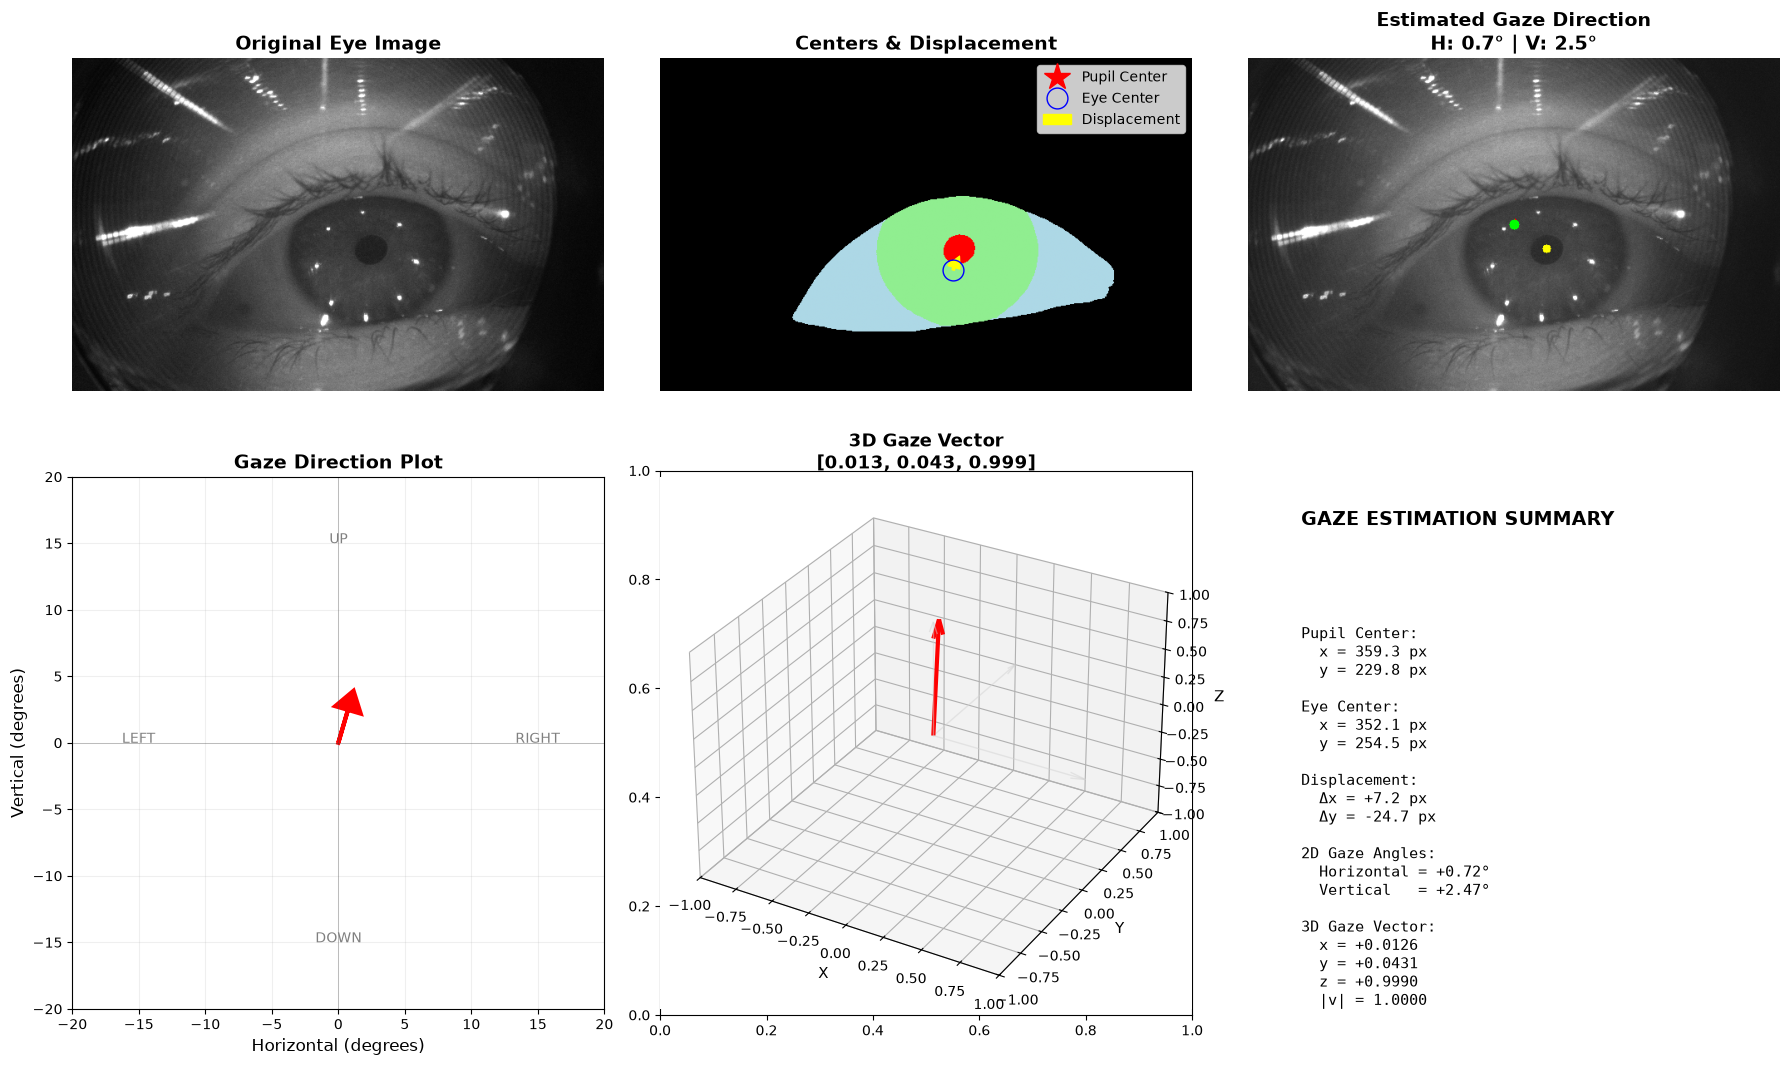


Successfully converted segmentation mask to gaze vector!
   You can now use this gaze vector: [0.01261426 0.0431295  0.99898985]


In [8]:
def estimate_gaze_from_mask(mask, image_shape=(400, 640)):
    """
    Estimate 3D gaze vector from segmentation mask
    
    Strategy:
    1. Find pupil center
    2. Find iris center (or eye center)
    3. Calculate displacement
    4. Convert to 3D gaze direction
    """
    
    # Extract pupil and iris masks
    pupil_mask = (mask == 3).astype(np.uint8)
    iris_mask = (mask == 2).astype(np.uint8)
    sclera_mask = (mask == 1).astype(np.uint8)
    
    # Combine for eye center estimation
    eye_mask = ((mask == 1) | (mask == 2) | (mask == 3)).astype(np.uint8)
    
    # Find pupil center using moments
    pupil_moments = cv2.moments(pupil_mask)
    if pupil_moments['m00'] > 0:
        pupil_cx = pupil_moments['m10'] / pupil_moments['m00'] #center of mass for x
        pupil_cy = pupil_moments['m01'] / pupil_moments['m00'] #center of mass for y
    else:
        print("No pupil found, using center")
        pupil_cx, pupil_cy = image_shape[1]//2, image_shape[0]//2
    
    # Find eye/iris center
    eye_moments = cv2.moments(eye_mask)
    if eye_moments['m00'] > 0:
        eye_cx = eye_moments['m10'] / eye_moments['m00'] #center of mass for x
        eye_cy = eye_moments['m01'] / eye_moments['m00']  #center of mass for y
    else:
        eye_cx, eye_cy = image_shape[1]//2, image_shape[0]//2 #If moments can't find the center of the iris find the center of the image
    
    # Calculate displacement (pupil relative to eye center)
    dx = pupil_cx - eye_cx  # Horizontal displacement (pixels)
    dy = pupil_cy - eye_cy  # Vertical displacement (pixels)
    
    # Convert pixel displacement to angular displacement
    # Assuming typical camera parameters for near-eye cameras
    # Approximate: 1 pixel ≈ 0.1 degrees for this resolution
    pixel_to_degree = 0.1
    
    theta_h = dx * pixel_to_degree  # Horizontal angle (degrees)
    theta_v = -dy * pixel_to_degree  # Vertical angle (degrees, negative because y increases downward)
    
    # Convert to radians
    theta_h_rad = np.radians(theta_h)
    theta_v_rad = np.radians(theta_v)
    
    # Create 3D gaze vector (unit vector)
    # Using spherical to Cartesian conversion
    x = np.sin(theta_h_rad) * np.cos(theta_v_rad)
    y = np.sin(theta_v_rad)
    z = np.cos(theta_h_rad) * np.cos(theta_v_rad)
    
    # Normalize to unit vector
    gaze_vector = np.array([x, y, z])
    gaze_vector = gaze_vector / np.linalg.norm(gaze_vector)
    
    return {
        'gaze_3d': gaze_vector,
        'gaze_2d_deg': (theta_h, theta_v),
        'gaze_2d_rad': (theta_h_rad, theta_v_rad),
        'pupil_center': (pupil_cx, pupil_cy),
        'eye_center': (eye_cx, eye_cy),
        'displacement_px': (dx, dy)
    }


# Load data
data_dir = '/work/cvcs2026/LZMM/OpenEDS'
openeds_path = os.path.join(data_dir, 'openEDS', 'openEDS')
subject_path = os.path.join(openeds_path, 'S_0')

image_path = os.path.join(subject_path, '0.png')
label_path = os.path.join(subject_path, '0.npy')

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
mask = np.load(label_path)

# Estimate gaze from mask
gaze_info = estimate_gaze_from_mask(mask, image.shape)

print("="*60)
print("GAZE ESTIMATION FROM SEGMENTATION MASK")
print("="*60)

print(f"\nPupil center: ({gaze_info['pupil_center'][0]:.1f}, {gaze_info['pupil_center'][1]:.1f})")
print(f"Eye center:   ({gaze_info['eye_center'][0]:.1f}, {gaze_info['eye_center'][1]:.1f})")
print(f"Displacement: ({gaze_info['displacement_px'][0]:.1f}, {gaze_info['displacement_px'][1]:.1f}) pixels")

print(f"\nEstimated 3D Gaze Vector:")
x, y, z = gaze_info['gaze_3d']
print(f"   [{x:.6f}, {y:.6f}, {z:.6f}]")
print(f"   Magnitude: {np.linalg.norm(gaze_info['gaze_3d']):.6f}")

theta_h, theta_v = gaze_info['gaze_2d_deg']
print(f"\nEstimated 2D Gaze Angles:")
print(f"   Horizontal: {theta_h:7.2f}°")
print(f"   Vertical:   {theta_v:7.2f}°")

print("\n" + "="*60)

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Original image
axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Original Eye Image', fontsize=14, fontweight='bold')
axes[0, 0].axis('off')

# 2. Segmentation mask with centers
colors = ['black', 'lightblue', 'lightgreen', 'red']
cmap = ListedColormap(colors)

axes[0, 1].imshow(mask, cmap=cmap, vmin=0, vmax=3)

# Mark pupil center
pupil_cx, pupil_cy = gaze_info['pupil_center']
axes[0, 1].plot(pupil_cx, pupil_cy, 'r*', markersize=20, label='Pupil Center')

# Mark eye center
eye_cx, eye_cy = gaze_info['eye_center']
axes[0, 1].plot(eye_cx, eye_cy, 'bo', markersize=15, fillstyle='none', 
                linewidth=3, label='Eye Center')

# Draw displacement vector
axes[0, 1].arrow(eye_cx, eye_cy, 
                 pupil_cx - eye_cx, pupil_cy - eye_cy,
                 color='yellow', width=3, head_width=15, 
                 length_includes_head=True, label='Displacement')

axes[0, 1].set_title('Centers & Displacement', fontsize=14, fontweight='bold')
axes[0, 1].legend(loc='upper right', fontsize=10)
axes[0, 1].axis('off')

# 3. Image with gaze arrow
img_rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
h, w = image.shape
cx, cy = w//2, h//2

# Draw gaze direction arrow
arrow_len = 100
theta_h_rad, theta_v_rad = gaze_info['gaze_2d_rad']
ex = int(cx + arrow_len * np.sin(theta_h_rad))
ey = int(cy - arrow_len * np.sin(theta_v_rad))

cv2.arrowedLine(img_rgb, (cx, cy), (ex, ey), (255, 0, 0), 4, tipLength=0.3)
cv2.circle(img_rgb, (cx, cy), 6, (0, 255, 0), -1)

# Also draw pupil center
cv2.circle(img_rgb, (int(pupil_cx), int(pupil_cy)), 5, (255, 255, 0), -1)

axes[0, 2].imshow(img_rgb)
axes[0, 2].set_title(f'Estimated Gaze Direction\nH: {theta_h:.1f}° | V: {theta_v:.1f}°', 
                     fontsize=14, fontweight='bold')
axes[0, 2].axis('off')

# 4. Gaze angle visualization
axes[1, 0].set_xlim(-20, 20)
axes[1, 0].set_ylim(-20, 20)
axes[1, 0].axhline(0, color='k', linewidth=0.5, alpha=0.3)
axes[1, 0].axvline(0, color='k', linewidth=0.5, alpha=0.3)
axes[1, 0].grid(True, alpha=0.2)

axes[1, 0].arrow(0, 0, theta_h, theta_v, 
                 head_width=2, head_length=1.5, 
                 fc='red', ec='red', linewidth=3)

axes[1, 0].set_xlabel('Horizontal (degrees)', fontsize=12)
axes[1, 0].set_ylabel('Vertical (degrees)', fontsize=12)
axes[1, 0].set_title('Gaze Direction Plot', fontsize=14, fontweight='bold')
axes[1, 0].set_aspect('equal')

# Add direction labels
axes[1, 0].text(15, 0, 'RIGHT', fontsize=10, ha='center', color='gray')
axes[1, 0].text(-15, 0, 'LEFT', fontsize=10, ha='center', color='gray')
axes[1, 0].text(0, 15, 'UP', fontsize=10, ha='center', color='gray')
axes[1, 0].text(0, -15, 'DOWN', fontsize=10, ha='center', color='gray')

# 5. 3D vector visualization
ax_3d = fig.add_subplot(2, 3, 5, projection='3d')

# Draw coordinate system
ax_3d.quiver(0, 0, 0, 1, 0, 0, color='lightgray', arrow_length_ratio=0.1, linewidth=1, alpha=0.5)
ax_3d.quiver(0, 0, 0, 0, 1, 0, color='lightgray', arrow_length_ratio=0.1, linewidth=1, alpha=0.5)
ax_3d.quiver(0, 0, 0, 0, 0, 1, color='lightgray', arrow_length_ratio=0.1, linewidth=1, alpha=0.5)

# Draw gaze vector
ax_3d.quiver(0, 0, 0, x, y, z, color='red', arrow_length_ratio=0.15, linewidth=3)

ax_3d.set_xlabel('X', fontsize=11)
ax_3d.set_ylabel('Y', fontsize=11)
ax_3d.set_zlabel('Z', fontsize=11)
ax_3d.set_title(f'3D Gaze Vector\n[{x:.3f}, {y:.3f}, {z:.3f}]', 
                fontsize=13, fontweight='bold')
ax_3d.set_xlim([-1, 1])
ax_3d.set_ylim([-1, 1])
ax_3d.set_zlim([-1, 1])

# 6. Pixel displacement analysis
axes[1, 2].text(0.1, 0.9, 'GAZE ESTIMATION SUMMARY', 
                fontsize=14, fontweight='bold', transform=axes[1, 2].transAxes)

summary_text = f"""
Pupil Center:
  x = {pupil_cx:.1f} px
  y = {pupil_cy:.1f} px

Eye Center:
  x = {eye_cx:.1f} px
  y = {eye_cy:.1f} px

Displacement:
  Δx = {gaze_info['displacement_px'][0]:+.1f} px
  Δy = {gaze_info['displacement_px'][1]:+.1f} px

2D Gaze Angles:
  Horizontal = {theta_h:+.2f}°
  Vertical   = {theta_v:+.2f}°

3D Gaze Vector:
  x = {x:+.4f}
  y = {y:+.4f}
  z = {z:+.4f}
  |v| = {np.linalg.norm(gaze_info['gaze_3d']):.4f}
"""

axes[1, 2].text(0.1, 0.75, summary_text, 
                fontsize=11, family='monospace',
                verticalalignment='top', transform=axes[1, 2].transAxes)
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("\nSuccessfully converted segmentation mask to gaze vector!")
print(f"   You can now use this gaze vector: {gaze_info['gaze_3d']}")

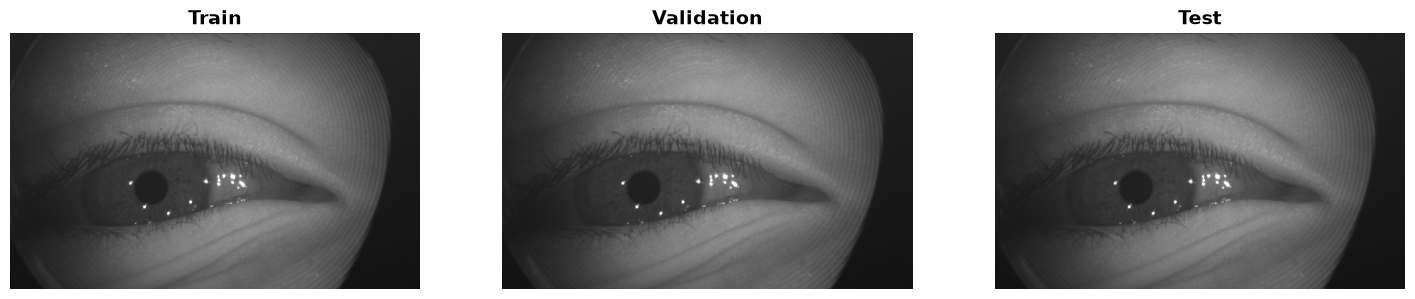

In [15]:
train_path = '/work/cvcs2026/LZMM/OpenEDS/openEDS/openEDS/train'
val_path = '/work/cvcs2026/LZMM/OpenEDS/openEDS/openEDS/validation'
test_path = '/work/cvcs2026/LZMM/OpenEDS/openEDS/openEDS/test'

fig, axes = plt.subplots(1, 3, figsize=(18, 12))

train_img = plt.imread(os.path.join(train_path, 'images/002010.png'))
axes[0].imshow(train_img, cmap='gray')
axes[0].set_title('Train', fontsize=14, fontweight='bold')
axes[0].axis('off')

val_img = plt.imread(os.path.join(val_path, 'images/002010.png'))
axes[1].imshow(val_img, cmap='gray')
axes[1].set_title('Validation', fontsize=14, fontweight='bold')
axes[1].axis('off')

test_img = plt.imread(os.path.join(test_path, 'images/002010.png'))
axes[2].imshow(test_img, cmap='gray')
axes[2].set_title('Test', fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.show()